In [43]:
import pandas as pd
import numpy as np

In [44]:
df= pd.read_csv("./datasets/outliers.csv", comment= '#')

In [45]:
df.head()

,cgpa,placement_exam_marks,placed
0,5.1,62,0
1,5.3,58,0
2,5.5,65,0
3,5.7,70,0
4,5.9,68,0


### Check the distribution of the columns

Text(0.5, 1.0, 'placement_exam_marks')

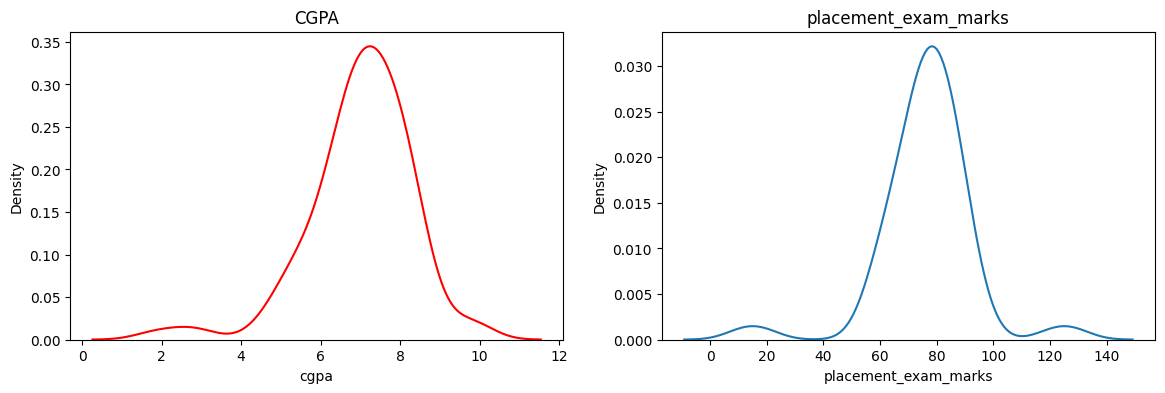

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 4))

plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'], color= 'red')
plt.title("CGPA")



plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'])
plt.title("placement_exam_marks")





## Z score method
    - This method is applicable for the column having normally distributed data
    - Anyvalue outside range (mean- 3*sd, mean + 3*sd) are outliers

In [47]:
#detecting the range

print(f"({df['placement_exam_marks'].mean()- 3 * df['placement_exam_marks'].std()}, {df['placement_exam_marks'].mean()+3 * df['placement_exam_marks'].std()})")
# any value outside this range are outliers

(27.75686704642567, 124.90979962024099)


In [48]:
#identifying the rows having this value

df[(df['placement_exam_marks'] > 124.90979962024099) | (df['placement_exam_marks']< 27.75686704642567)]

,cgpa,placement_exam_marks,placed
84,6.8,125,1
85,7.5,130,1
86,6.9,20,0
87,7.1,15,0
88,6.7,10,0


In [49]:
df[(df['placement_exam_marks'] <= 124.90979962024099) & (df['placement_exam_marks']>= 27.75686704642567)]

,cgpa,placement_exam_marks,placed
0,5.1,62,0
1,5.3,58,0
2,5.5,65,0
3,5.7,70,0
4,5.9,68,0
...,...,...,...
100,8.1,85,1
101,5.4,60,0
102,6.2,70,0
103,7.6,80,1


In [50]:
df.shape

(105, 3)

In [55]:
# Method 2 is to capping them i.e replacing value greater than upper limit by upper limit and value lower than lower limit by lower limit

df['placement_exam_marks']= np.where(
    df['placement_exam_marks']> 124.90979962024099,
    124.90979962024099,
    np.where(
        df['placement_exam_marks']< 27.75686704642567,
        27.75686704642567,
        df['placement_exam_marks']
    )

)


In [56]:
df

,cgpa,placement_exam_marks,placed
0,5.1,62.0,0
1,5.3,58.0,0
2,5.5,65.0,0
3,5.7,70.0,0
4,5.9,68.0,0
...,...,...,...
100,8.1,85.0,1
101,5.4,60.0,0
102,6.2,70.0,0
103,7.6,80.0,1


Text(0.5, 1.0, 'placement_exam_marks')

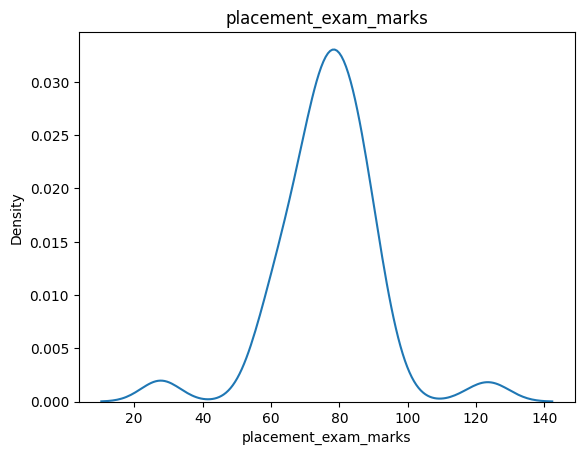

In [57]:

sns.kdeplot(df['placement_exam_marks'])
plt.title("placement_exam_marks")

In [ ]:
df[(df['placement_exam_marks'] > 124.90979962024099) | (df['placement_exam_marks']< 27.75686704642567)]

# shows no any outliers

,cgpa,placement_exam_marks,placed


In [59]:
##using loc
df.loc[df['placement_exam_marks'] > 124.90979962024099, 'placement_exam_marks']=  124.90979962024099
df.loc[df['placement_exam_marks'] < 27.75686704642567, 'placement_exam_marks']=  27.75686704642567

## Using IQR
    - is done for column having skewed data
    - anything outside range of (Q1 - 1.5*IQR and Q3 + 1.5 * IQR ) is considered outliers
    

In [60]:
df['cgpa'].describe()

count    105.000000
mean       7.003810
std        1.303982
min        1.800000
25%        6.400000
50%        7.100000
75%        7.800000
max       10.000000
Name: cgpa, dtype: float64

In [66]:
q1= df['cgpa'].quantile(0.25)
q3= df['cgpa'].quantile(0.75)

iqr= q3-q1

In [67]:
print(f'({q1-1.5*iqr}, {q3+1.5*iqr})')

(4.300000000000001, 9.899999999999999)


Text(0.5, 1.0, 'before removing outliers')

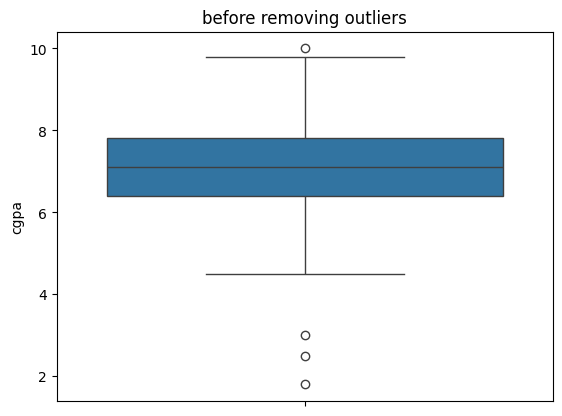

In [68]:
sns.boxplot(df['cgpa'])
plt.title("before removing outliers")

In [70]:
# cappinp the outliers
df['cgpa']= np.where(
    df['cgpa']> 9.899999999999999,
    9.899999999999999,
    np.where(
        df['cgpa']< 4.300000000000001,
        4.300000000000001,
        df['cgpa']
    )
)


'''
np.where(
condition,
executed if true,
executed if false)'''

'\nnp.where(\ncondition,\nexecuted if true,\nexecuted if false)'

Text(0.5, 1.0, 'After clapping outliers')

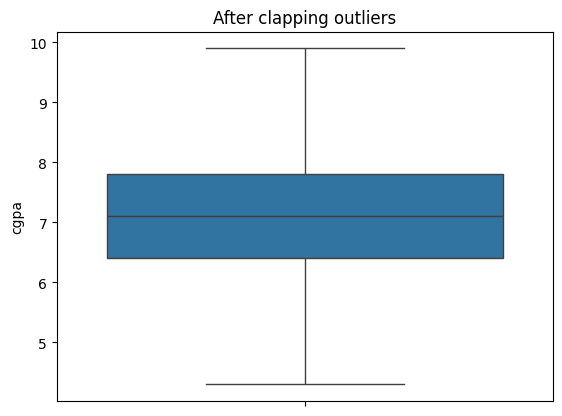

In [71]:
sns.boxplot(df['cgpa'])
plt.title("After clapping outliers")